# Exoplanetas: lo que sabemos está moldeado por cómo buscamos

Análisis exploratorio (EDA) de la población de exoplanetas confirmados del
[NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/).

**Tesis central:** el método usado para descubrir un exoplaneta (tránsito,
velocidad radial, microlente, imagen directa) condiciona *qué* planetas
encontramos — y por lo tanto distorsiona lo que creemos saber sobre la
población real de exoplanetas.

**Fuente de datos:** tabla `PSCompPars` (Planetary Systems Composite
Parameters), que consolida una fila por planeta confirmado. Se descarga de
forma reproducible con `src/download_data.py` vía el servicio TAP del archivo.

## 1. Carga de datos

El CSV crudo vive en `data/raw/` y nunca se edita a mano. Si el archivo no
existe, hay que generarlo primero corriendo (desde la raíz del repo):

```
python src/download_data.py
```

In [1]:
from pathlib import Path

import pandas as pd

# Ruta relativa al notebook: el CSV crudo descargado por src/download_data.py
RAW_DATA_PATH = Path("..") / "data" / "raw" / "pscomppars.csv"

df = pd.read_csv(RAW_DATA_PATH)
print(f"{df.shape[0]} filas (planetas) x {df.shape[1]} columnas")

6316 filas (planetas) x 12 columnas


In [2]:
df.head()

,pl_name,discoverymethod,disc_year,pl_bmasse,pl_bmassprov,pl_rade,pl_orbper,pl_orbsmax,pl_eqt,sy_dist,st_teff,st_rad
0,Kepler-1597 b,Transit,2016,1.20,M-R relationship,1.06,2.946542,0.04136,1497.0,1221.050,6377.0,1.390
1,Kepler-687 b,Transit,2016,12.20,M-R relationship,3.52,20.505870,0.13260,518.0,633.660,4841.0,0.730
2,Kepler-1596 b,Transit,2016,4.27,M-R relationship,1.90,66.373379,0.32370,471.0,2146.230,5706.0,0.920
3,Kepler-692 b,Transit,2016,9.85,M-R relationship,3.11,21.812935,0.14950,639.0,991.336,5440.0,0.860
4,Kepler-150 c,Transit,2014,13.20,M-R relationship,3.69,7.381998,0.07300,876.0,891.092,5560.0,0.939


## 2. Perfilado y limpieza

Antes de preguntarle nada a los datos hay que entender su forma real: tipos,
duplicados, faltantes y rangos. En este dataset la limpieza no es un trámite:
el patrón de datos faltantes está directamente ligado al método de detección,
así que perfilar ya es empezar a responder la tesis.

Cada decisión de limpieza queda documentada y justificada en su propia celda.

### 2.1 Dimensiones, tipos y duplicados

**Pregunta:** ¿la tabla tiene la estructura prometida — una fila por planeta,
con los tipos de dato correctos?

In [3]:
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print(df.dtypes)
print(f"\nPlanetas duplicados (pl_name repetido): {df['pl_name'].duplicated().sum()}")

Dimensiones: 6316 filas x 12 columnas

pl_name                str
discoverymethod        str
disc_year            int64
pl_bmasse          float64
pl_bmassprov           str
pl_rade            float64
pl_orbper          float64
pl_orbsmax         float64
pl_eqt             float64
sy_dist            float64
st_teff            float64
st_rad             float64
dtype: object

Planetas duplicados (pl_name repetido): 0


**Conclusión:** la tabla cumple lo prometido: una fila por planeta, cero
nombres duplicados (a diferencia de la tabla `PS`, que trae una fila por
publicación y exige deduplicar). Los tipos vienen correctos de entrada:
texto en las categóricas, entero en el año y `float64` en las variables
físicas — no hay números "atrapados" en columnas de texto.

### 2.2 Datos faltantes por columna

**Pregunta:** ¿cuánto falta en cada columna?

In [4]:
nulls = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(1),
}).sort_values("pct_nulos", ascending=False)
nulls

,n_nulos,pct_nulos
pl_eqt,526,8.3
pl_orbsmax,429,6.8
pl_orbper,343,5.4
st_rad,321,5.1
st_teff,297,4.7
pl_rade,50,0.8
pl_bmasse,31,0.5
sy_dist,27,0.4
disc_year,0,0.0
discoverymethod,0,0.0


**Conclusión:** ninguna columna supera el 9% de faltantes y las columnas de
identidad (nombre, método, año) están completas. Pero hay algo sospechoso:
masa (0,5%) y radio (0,8%) casi no tienen nulos, siendo que medir *ambos*
para un mismo planeta es difícil — en general requiere combinar dos técnicas
de detección distintas. Esa completitud es demasiado buena para ser verdad;
lo investigamos a continuación.

### 2.3 La completitud ilusoria: ¿de dónde sale la masa?

**Pregunta:** ¿cuántas masas están realmente medidas y cuántas son estimaciones?

`PSCompPars` es una tabla *compuesta*: cuando no existe una masa medida, el
archivo la rellena con una estimación derivada de la relación masa-radio.
La columna `pl_bmassprov` registra la procedencia de cada valor.

In [5]:
print(df["pl_bmassprov"].value_counts(), "\n")

# Cruce método x procedencia, solo los 4 métodos con más descubrimientos
top4 = df["discoverymethod"].value_counts().head(4).index
pd.crosstab(df.loc[df["discoverymethod"].isin(top4), "discoverymethod"],
            df["pl_bmassprov"])

pl_bmassprov
M-R relationship    2977
Mass                2402
Msini                922
Msin(i)/sin(i)        15
Name: count, dtype: int64 



pl_bmassprov,M-R relationship,Mass,Msin(i)/sin(i),Msini
discoverymethod,,,,
Imaging,0,94,0,3
Microlensing,0,281,0,0
Radial Velocity,0,321,10,865
Transit,2974,1647,2,36


**Conclusión:** solo 2.402 planetas (38%) tienen masa medida (`Mass`). El 47%
usa la relación masa-radio (`M-R relationship`) — y casi todos esos son
planetas de tránsito: **el 64% de las masas de los planetas de tránsito son
estimaciones, no mediciones**. Otros ~940 valores son `Msini`: una cota
inferior de la masa (la inclinación de la órbita es desconocida), típica de
velocidad radial. Primera evidencia dura de la tesis: hasta la "completitud"
del dataset depende del método de detección.

### 2.4 Datos faltantes por método de detección

**Pregunta:** ¿el patrón de faltantes es aleatorio, o cada método tiene sus
propios puntos ciegos?

In [6]:
phys_cols = ["pl_bmasse", "pl_rade", "pl_orbper", "pl_orbsmax",
             "pl_eqt", "sy_dist", "st_teff", "st_rad"]

# % de nulos en cada columna física, desagregado por método de detección
nulls_by_method = (df.groupby("discoverymethod")[phys_cols]
                     .apply(lambda g: g.isna().mean() * 100)
                     .round(1))
nulls_by_method.insert(0, "n_planetas", df["discoverymethod"].value_counts())
nulls_by_method.sort_values("n_planetas", ascending=False)

,n_planetas,pl_bmasse,pl_rade,pl_orbper,pl_orbsmax,pl_eqt,sy_dist,st_teff,st_rad
discoverymethod,,,,,,,,,
Transit,4659,0.5,0.0,0.0,7.8,3.6,0.3,0.0,0.0
Radial Velocity,1196,0.1,3.1,0.0,3.4,3.6,0.1,0.2,0.5
Microlensing,281,0.0,0.0,95.7,2.1,97.9,0.7,97.9,99.6
Imaging,97,3.1,4.1,74.2,1.0,8.2,6.2,9.3,19.6
Transit Timing Variations,40,2.5,2.5,0.0,12.5,12.5,0.0,0.0,0.0
Eclipse Timing Variations,17,0.0,11.8,0.0,17.6,58.8,5.9,5.9,41.2
Orbital Brightness Modulation,9,33.3,33.3,0.0,66.7,66.7,0.0,0.0,0.0
Pulsar Timing,8,0.0,25.0,12.5,12.5,100.0,25.0,87.5,100.0
Astrometry,6,0.0,0.0,0.0,33.3,50.0,0.0,16.7,16.7


**Conclusión:** los faltantes NO son aleatorios — son la huella digital de
cada técnica. Microlente detecta planetas lejanos mediante eventos únicos e
irrepetibles: no caracteriza la estrella (98–100% de nulos en temperatura y
radio estelar) ni el período orbital (96%). Imagen directa resuelve órbitas
enormes que tardan décadas o siglos: 74% sin período. Tránsito y velocidad
radial, en cambio, vienen casi completos. En jerga estadística los datos son
**MNAR** (*missing not at random*): imputar o botar filas a ciegas
destruiría exactamente el sesgo que queremos estudiar.

### 2.5 Estadísticas descriptivas

**Pregunta:** ¿en qué rangos viven las variables físicas? ¿Hay valores
imposibles que delaten errores de datos?

In [7]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
disc_year,6316.0,2017.22,5.11,1992.00,2014.00,2016.00,2021.00,2.026000e+03
pl_bmasse,6285.0,403.66,1137.52,0.02,4.30,9.27,188.47,9.534850e+03
pl_rade,6266.0,5.83,5.42,0.31,1.84,2.85,11.90,8.721000e+01
pl_orbper,5973.0,71668.12,5203948.37,0.09,4.31,10.74,38.48,4.020000e+08
pl_orbsmax,5887.0,15.60,347.47,0.00,0.05,0.10,0.31,1.900000e+04
pl_eqt,5790.0,833.81,495.38,1.48,485.90,755.00,1092.00,7.777780e+03
sy_dist,6289.0,705.15,1216.60,1.30,101.26,360.92,824.31,8.500000e+03
st_teff,6019.0,5392.96,1729.82,415.00,4898.00,5543.00,5897.00,5.700000e+04
st_rad,5995.0,1.49,3.87,0.01,0.77,0.95,1.24,8.848000e+01


**Conclusión:** no hay valores físicamente imposibles (todos los mínimos son
positivos). Pero los rangos abarcan órdenes de magnitud: la masa va de
centésimas a ~9.500 masas terrestres, y el período orbital desde horas hasta
~400 millones de días (¡un planeta de imagen directa con una órbita de un
millón de años!). Con colas así, la media y la desviación estándar pierden
sentido — cuando grafiquemos estas variables será obligatorio usar escala
logarítmica.

### 2.6 Decisiones de limpieza

Con el perfil claro, las decisiones — cada una con su porqué:

1. **No se elimina ninguna fila.** Los faltantes son MNAR: botar filas con
   nulos eliminaría en la práctica a casi todos los planetas de microlente e
   imagen directa, inyectando el mismo sesgo que estudiamos. Cada análisis
   filtrará solo por las columnas que necesita.
2. **No se imputa ninguna variable física.** El dataset ya trae imputación de
   fábrica (las masas M-R); agregar más valores inventados, correlacionados
   con el método, contaminaría las conclusiones. Preferimos menos datos pero
   honestos.
3. **Se agrega `mass_is_estimated`** (booleano): marca las masas que provienen
   de la relación masa-radio, para poder excluirlas o señalarlas en los
   análisis que dependan de la masa.
4. **Se agrega `method_grouped`**: los 7 métodos con menos del 1% de los
   planetas cada uno (83 en total) se agrupan como `Other` para que los
   gráficos por método sean legibles. La columna original se conserva.
5. **Los valores extremos se quedan.** No son errores: son física real. La
   estrategia es escala logarítmica, no recorte.

El resultado se guarda en `data/processed/` — regenerable de principio a fin.

In [8]:
df_clean = df.copy()

# (3) Marcar masas estimadas por relación masa-radio
df_clean["mass_is_estimated"] = df_clean["pl_bmassprov"].eq("M-R relationship")

# (4) Agrupar métodos minoritarios (<1% del total) bajo "Other"
main_methods = ["Transit", "Radial Velocity", "Microlensing", "Imaging"]
df_clean["method_grouped"] = (df_clean["discoverymethod"]
                              .where(df_clean["discoverymethod"].isin(main_methods),
                                     "Other"))

print(df_clean["method_grouped"].value_counts(), "\n")
print(f"Masas estimadas por relación M-R: {df_clean['mass_is_estimated'].sum()}")

method_grouped
Transit            4659
Radial Velocity    1196
Microlensing        281
Imaging              97
Other                83
Name: count, dtype: int64 

Masas estimadas por relación M-R: 2977


In [9]:
PROCESSED_PATH = Path("..") / "data" / "processed" / "pscomppars_clean.csv"
df_clean.to_csv(PROCESSED_PATH, index=False)

# Verificación: el archivo se relee con las mismas dimensiones
check = pd.read_csv(PROCESSED_PATH)
assert check.shape == df_clean.shape
print(f"Guardado {PROCESSED_PATH} -> {check.shape[0]} filas x {check.shape[1]} columnas")

Guardado ..\data\processed\pscomppars_clean.csv -> 6316 filas x 14 columnas


## 3. EDA univariado: la forma de la población

Primer nivel de preguntas: el *qué*. Antes de cruzar variables hay que
entender cada una por separado — no se pueden interpretar relaciones entre
distribuciones que no conocemos.

Trabajamos sobre `df_clean` (sección 2.6). Cada pregunta sigue la misma
estructura: **pregunta → gráfico → conclusión**.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Estilo único para todos los gráficos del notebook:
# un color de acento para la serie principal y un gris para el contexto
sns.set_theme(style="whitegrid", context="notebook")
ACCENT = "#4C72B0"   # azul sobrio
MUTED = "#C3CBD6"    # gris azulado

### 3.1 ¿Con qué métodos se han descubierto los exoplanetas?

**Pregunta:** ¿cómo se reparte el catálogo entre los métodos de detección?

Acá usamos `discoverymethod` completo (las 11 categorías) y no
`method_grouped`: el objetivo es mostrar la distribución real, incluidos los
métodos exóticos. El agrupamiento queda para los gráficos comparativos de la
sección 4.

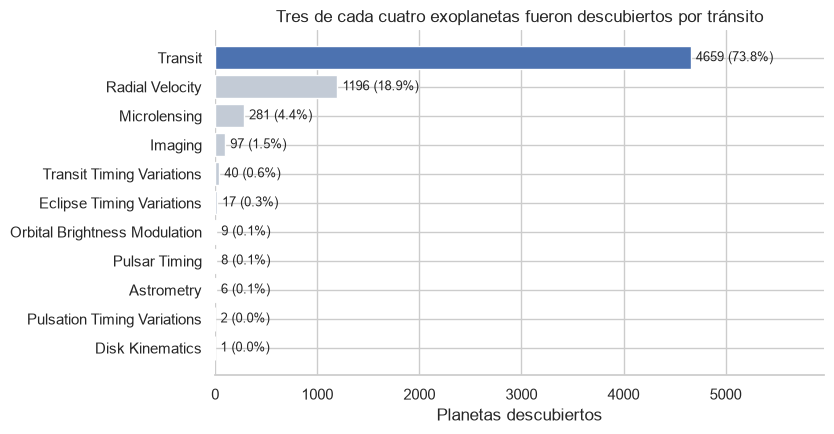

In [11]:
method_counts = df_clean["discoverymethod"].value_counts()
total = len(df_clean)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
# Destacar el método dominante; el resto queda en gris de contexto
colors = [ACCENT if m == "Transit" else MUTED for m in method_counts.index]
ax.barh(method_counts.index, method_counts.values, color=colors)
ax.invert_yaxis()  # el más frecuente arriba

# Etiquetas directas: con esta disparidad, leer el eje no alcanza
for i, val in enumerate(method_counts.values):
    ax.text(val + total * 0.008, i, f"{val} ({val / total * 100:.1f}%)",
            va="center", fontsize=9)

ax.set_xlim(0, method_counts.max() * 1.28)
ax.set_xlabel("Planetas descubiertos")
ax.set_title("Tres de cada cuatro exoplanetas fueron descubiertos por tránsito")
sns.despine(left=True)
plt.tight_layout()
plt.show()

**Conclusión:** el tránsito aporta el **73,8%** de todos los exoplanetas
conocidos, y la velocidad radial otro 18,9%: entre los dos concentran el 93%
del catálogo. Cualquier afirmación sobre "el exoplaneta típico" es, en la
práctica, una afirmación sobre lo que estos dos métodos son capaces de ver.
Los otros nueve métodos juntos aportan menos del 8% — y como vimos en 2.4,
son justamente los que exploran las regiones donde tránsito y velocidad
radial son ciegos.

### 3.2 ¿Cómo evolucionó el ritmo de descubrimientos?

**Pregunta:** ¿los exoplanetas se descubren a un ritmo constante, o hay
quiebres en la serie temporal?

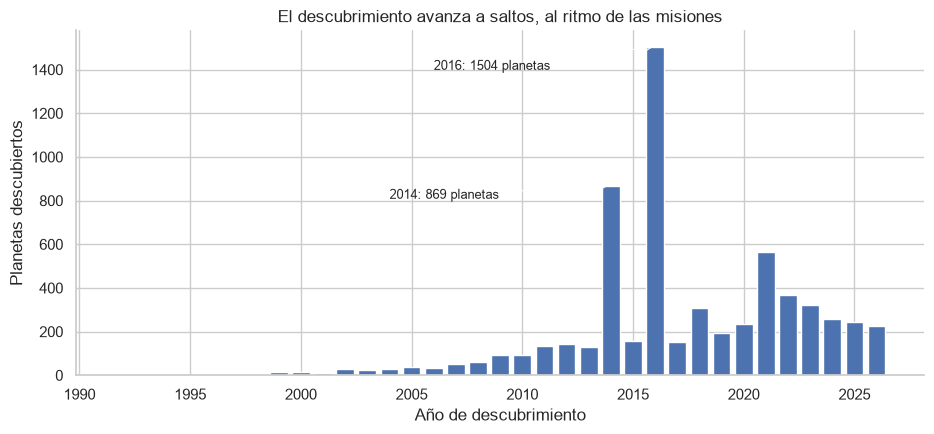

In [12]:
year_counts = df_clean["disc_year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(year_counts.index, year_counts.values, color=ACCENT, width=0.8)

# Anotar los dos años peak (corresponden a validaciones masivas del catálogo Kepler)
for year, count in year_counts.nlargest(2).items():
    ax.annotate(f"{year}: {count} planetas", xy=(year, count),
                xytext=(year - 10, count * 0.93),
                arrowprops=dict(arrowstyle="->", lw=0.8), fontsize=9)

ax.set_xlabel("Año de descubrimiento")
ax.set_ylabel("Planetas descubiertos")
ax.set_title("El descubrimiento avanza a saltos, al ritmo de las misiones")
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión:** el descubrimiento no avanza parejo — salta con cada
instrumento. Hasta 2009 (era de la velocidad radial, desde telescopios en
tierra) se confirmaban decenas de planetas al año. El telescopio espacial
Kepler (2009) industrializó el método del tránsito, y los dos peaks del
gráfico no son años milagrosos: son **publicaciones masivas de validaciones
del catálogo Kepler**. El ritmo lo dictan los instrumentos y sus pipelines de
análisis, no un progreso continuo. (El último año aparece bajo simplemente
porque aún no termina.)

### 3.3 ¿Cómo se distribuyen las variables físicas clave?

**Pregunta:** ¿qué forma tienen las distribuciones de radio, masa y período
orbital?

El perfilado (2.5) mostró que estas variables abarcan varios órdenes de
magnitud, así que los histogramas usan bins logarítmicos — en escala lineal
todo el detalle quedaría aplastado contra el origen.

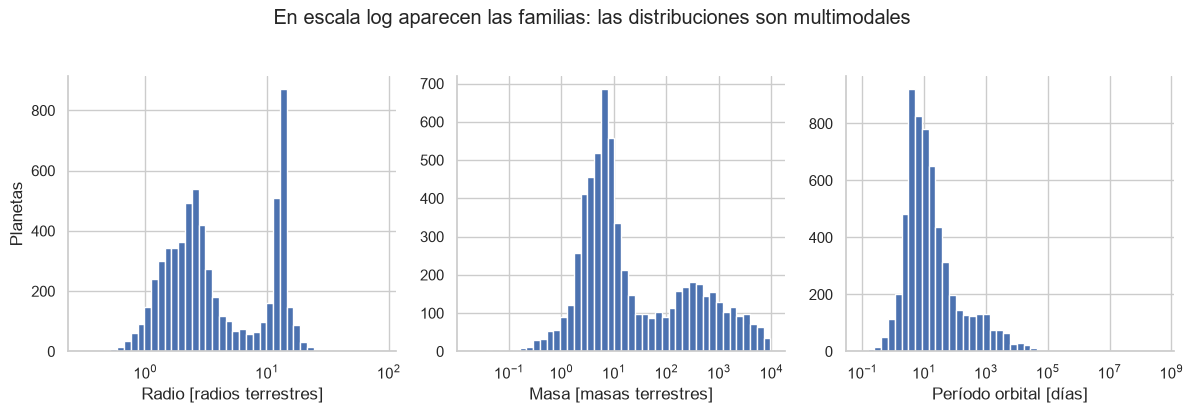

In [13]:
phys_vars = [
    ("pl_rade", "Radio [radios terrestres]"),
    ("pl_bmasse", "Masa [masas terrestres]"),
    ("pl_orbper", "Período orbital [días]"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (col, label) in zip(axes, phys_vars):
    data = df_clean[col].dropna()
    # Bins log-espaciados: estas variables viven en órdenes de magnitud,
    # con bins lineales todo se apila en la primera barra
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 45)
    ax.hist(data, bins=bins, color=ACCENT)
    ax.set_xscale("log")
    ax.set_xlabel(label)
axes[0].set_ylabel("Planetas")
fig.suptitle("En escala log aparecen las familias: las distribuciones son multimodales",
             y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión:** las tres distribuciones solo se leen en escala logarítmica. El
radio es bimodal: abundan los planetas de 1–3 radios terrestres (super-Tierras
y sub-Neptunos, familias que no existen en el Sistema Solar) y los gigantes
tipo Júpiter (~10–15 radios). La masa repite el patrón a su manera. Y el
período orbital es lo más revelador: **la mitad del catálogo orbita en menos
de 11 días** — mucho más cerca de su estrella que Mercurio del Sol (88 días).
¿Son realmente los planetas "pegados" a su estrella los más comunes del
universo, o solo los más fáciles de detectar? Esa es exactamente la pregunta
de la sección 4.

## 4. EDA bivariado: cada método ve un universo distinto

El núcleo del análisis. La sección 3 mostró *qué* hay en el catálogo; esta
sección muestra que ese contenido **depende de cómo se buscó**. Cruzamos el
método de detección con las variables físicas para hacer visible el sesgo:
si los métodos fueran ventanas neutras, las distribuciones por método serían
parecidas. No lo son — y esa es la tesis.

Desde aquí usamos `method_grouped` (los 4 métodos principales + `Other`),
con un color fijo por método en todos los gráficos.

In [14]:
# Orden y colores fijos por método para toda la sección:
# el lector asocia un color a un método una sola vez
# (paleta apta para daltonismo, basada en la "colorblind" de seaborn)
METHOD_ORDER = ["Transit", "Radial Velocity", "Microlensing", "Imaging", "Other"]
METHOD_COLORS = {
    "Transit": "#0173B2",          # azul
    "Radial Velocity": "#DE8F05",  # naranjo
    "Microlensing": "#029E73",     # verde
    "Imaging": "#D55E00",          # rojo ladrillo
    "Other": "#949494",            # gris
}

### 4.1 ¿Qué tamaño de planeta descubre cada método?

**Pregunta:** ¿la masa de los planetas encontrados depende del método que los
encontró?

Comparamos con boxplots la distribución de masa por método. Como la masa
abarca 5 órdenes de magnitud (2.5), el eje va en escala logarítmica.

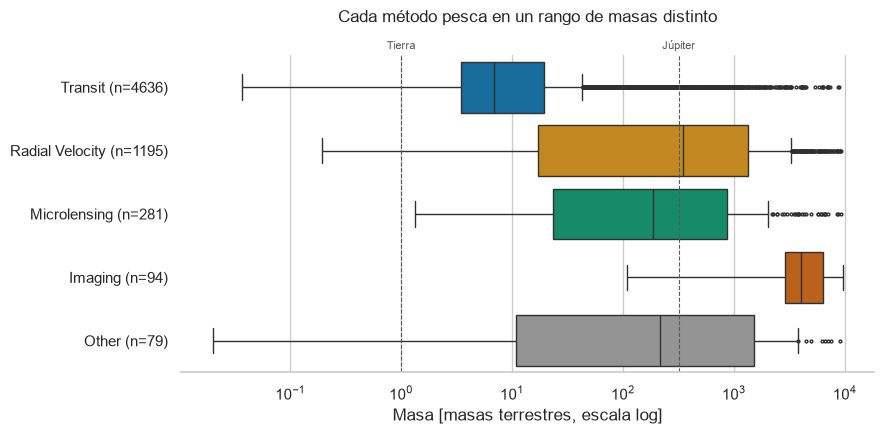

In [15]:
data = df_clean.dropna(subset=["pl_bmasse"])
counts = data["method_grouped"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=data, y="method_grouped", x="pl_bmasse", order=METHOD_ORDER,
            hue="method_grouped", palette=METHOD_COLORS, legend=False,
            fliersize=2, ax=ax)
ax.set_xscale("log")

# Masas de referencia del Sistema Solar (etiquetas sobre el borde superior)
for mass, name in [(1.0, "Tierra"), (317.8, "Júpiter")]:
    ax.axvline(mass, color="0.35", lw=0.8, ls="--")
    ax.text(mass, -0.6, name, fontsize=8, color="0.35", ha="center")

ax.set_xlabel("Masa [masas terrestres, escala log]")
ax.set_ylabel("")
ax.set_yticks(range(len(METHOD_ORDER)),
              [f"{m} (n={counts[m]})" for m in METHOD_ORDER])
ax.set_title("Cada método pesca en un rango de masas distinto", pad=24)
sns.despine(left=True)
plt.tight_layout()
plt.show()

**Conclusión:** la mediana de masa cambia **~600 veces** según a qué método le
preguntes: 6,9 M⊕ en tránsito (super-Tierras y sub-Neptunos), ~350 M⊕
(≈1,1 masas de Júpiter) en velocidad radial, ~190 M⊕ en microlente y ~4.100 M⊕
(≈13 M_Júp, al borde del límite con las enanas cafés) en imagen directa. No es
que existan "los planetas típicos": cada técnica pesca en un estanque de masas
distinto. Nota de honestidad: el 64% de las masas de tránsito son estimaciones
M-R (sección 2.3) — suficiente para comparar órdenes de magnitud, no valores
finos.

### 4.2 ¿Los métodos favorecen planetas cercanos o lejanos a su estrella?

**Pregunta:** ¿a qué distancia de su estrella están los planetas que cada
método encuentra?

Usamos el semi-eje mayor (`pl_orbsmax`) y no el período: representa la misma
física (qué tan lejos orbita el planeta) pero tiene muchos menos nulos en
microlente e imagen directa (ver 2.4), justo los métodos que exploran las
distancias grandes.

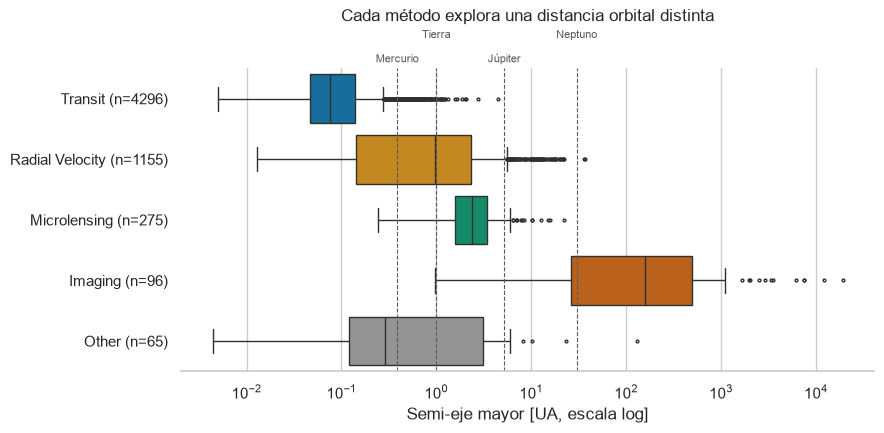

In [16]:
data = df_clean.dropna(subset=["pl_orbsmax"])
counts = data["method_grouped"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=data, y="method_grouped", x="pl_orbsmax", order=METHOD_ORDER,
            hue="method_grouped", palette=METHOD_COLORS, legend=False,
            fliersize=2, ax=ax)
ax.set_xscale("log")

# Órbitas del Sistema Solar; las etiquetas alternan altura para no chocar
# (Mercurio y Tierra quedan muy juntos en escala log)
refs = [(0.387, "Mercurio", -0.6), (1.0, "Tierra", -1.0),
        (5.2, "Júpiter", -0.6), (30.1, "Neptuno", -1.0)]
for au, name, y_label in refs:
    ax.axvline(au, color="0.35", lw=0.8, ls="--")
    ax.text(au, y_label, name, fontsize=8, color="0.35", ha="center")

ax.set_xlabel("Semi-eje mayor [UA, escala log]")
ax.set_ylabel("")
ax.set_yticks(range(len(METHOD_ORDER)),
              [f"{m} (n={counts[m]})" for m in METHOD_ORDER])
ax.set_title("Cada método explora una distancia orbital distinta", pad=34)
sns.despine(left=True)
plt.tight_layout()
plt.show()

**Conclusión:** los métodos no compiten — se reparten el sistema planetario
casi sin solaparse. El tránsito vive pegado a la estrella (mediana 0,076 UA,
cinco veces más adentro que Mercurio), velocidad radial llega hasta ~1 UA,
microlente puebla la franja fría de 1,6–3,4 UA (cerca de la "línea de hielo",
donde se forman los gigantes), e imagen directa parte donde todos los demás
terminan (mediana 156 UA, cinco veces la órbita de Neptuno). La región
5–25 UA — donde viven Júpiter, Saturno y Urano — queda en un vacío de
cobertura: si nuestro propio Sistema Solar orbitara otra estrella, casi no
podríamos detectarlo.

### 4.3 El mapa completo: masa vs. distancia orbital, coloreado por método

**Pregunta:** ¿cómo se reparte el espacio de parámetros completo entre los
métodos — y dónde caería el Sistema Solar en ese mapa?

**Nota de diseño:** el plan natural era graficar masa vs. *período orbital*,
pero la sección 2.4 mostró que el período falta justo donde más importa: 96%
de nulos en microlente y 74% en imagen directa. Usar el período borraría del
mapa a los dos métodos que ven lo que tránsito y velocidad radial no ven —
amputaría el sesgo que queremos mostrar. Usamos el **semi-eje mayor** (6,8%
de nulos): representa la misma física (distancia a la estrella) y por la
tercera ley de Kepler ($P^2 \propto a^3$) es informacionalmente equivalente.

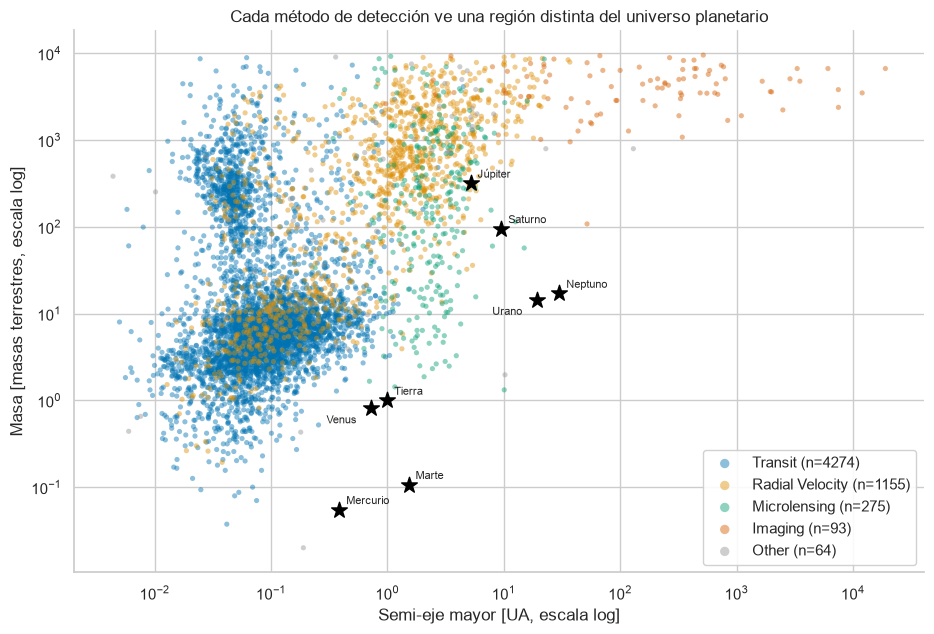

In [17]:
data = df_clean.dropna(subset=["pl_bmasse", "pl_orbsmax"])

fig, ax = plt.subplots(figsize=(9.5, 6.5))
for method in METHOD_ORDER:
    sub = data[data["method_grouped"] == method]
    ax.scatter(sub["pl_orbsmax"], sub["pl_bmasse"], s=14, alpha=0.45,
               color=METHOD_COLORS[method], label=f"{method} (n={len(sub)})",
               edgecolors="none")

# El Sistema Solar como referencia: ¿dónde caerían nuestros propios planetas?
solar_system = {
    "Mercurio": (0.387, 0.055), "Venus": (0.723, 0.815), "Tierra": (1.0, 1.0),
    "Marte": (1.524, 0.107), "Júpiter": (5.203, 317.8), "Saturno": (9.537, 95.2),
    "Urano": (19.19, 14.5), "Neptuno": (30.07, 17.1),
}
# Venus y Urano llevan la etiqueta a la izquierda para no chocar
# con Tierra y Neptuno, sus vecinos en el plano
label_offsets = {"Venus": (-32, -11), "Urano": (-32, -11)}
for name, (a, m) in solar_system.items():
    ax.scatter(a, m, marker="*", s=140, color="black", zorder=5)
    ax.annotate(name, (a, m), xytext=label_offsets.get(name, (5, 4)),
                textcoords="offset points", fontsize=8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Semi-eje mayor [UA, escala log]")
ax.set_ylabel("Masa [masas terrestres, escala log]")
ax.set_title("Cada método de detección ve una región distinta del universo planetario")
ax.legend(loc="lower right", framealpha=0.9, markerscale=1.8)
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión:** el plano masa–distancia está repartido en territorios casi
disjuntos: tránsito (azul) domina abajo a la izquierda — planetas pequeños
pegados a su estrella —, velocidad radial (naranjo) los gigantes a distancias
intermedias, microlente (verde) la franja fría de 1–10 UA, e imagen directa
(rojo) los super-Júpiters a decenas o cientos de UA. Las estrellas negras del
Sistema Solar muestran el punto ciego: **la Tierra cae en tierra de nadie**,
una región donde ningún método es eficiente, y nuestros gigantes (5–30 UA)
quedan en el hueco entre velocidad radial e imagen directa. Un Júpiter
caliente parece "típico" no porque abunde, sino porque dos métodos lo ven
fácil. **El catálogo es el mapa de nuestras herramientas, no del territorio.**